# WebRTC Heart Sound Quality Analysis
## ระบบ Telemedicine — การประเมินคุณภาพเสียงหัวใจผ่าน WebRTC

**วัตถุประสงค์:** เปรียบเทียบคุณภาพเสียงหัวใจที่ส่งผ่านเส้นทางต่าง ๆ กับต้นฉบับ เพื่อประเมินความเหมาะสมทางการแพทย์

| ชุดทดสอบ | เทคโนโลยี | คำอธิบาย |
|---------|-----------|---------|
| Test01 | WebRTC Opus | baseline — codec มาตรฐาน, recording ด้วย AudioRecord |
| Test02 | DataChannel PCM | ส่ง raw PCM float32 ไม่ผ่าน codec |
| Test03 | DataChannel PCM + Auto-sync | เพิ่ม Firestore signal auto-trigger recording |
| Test04 | DataChannel PCM + Lifecycle fix | แก้ stale-closure bug + DataChannel state check |

---

### เกณฑ์ประเมิน (Project-defined threshold, อ้างอิงจากวรรณกรรม)

**ช่วงความถี่ S1/S2 (60–150 Hz)** — อ้างอิงจาก:
> Leng S. et al., "The electronic stethoscope," *Biomedical Engineering Online* **14**, 66 (2015).
> doi: [10.1186/s12938-015-0056-y](https://doi.org/10.1186/s12938-015-0056-y)
>
> — S1 peak energy: ~50 Hz, S2 peak energy: ~100 Hz, diagnostic range: 20–500 Hz

| Band | ช่วง Hz | เกณฑ์ | เหตุผล |
|------|---------|-------|--------|
| **S1/S2 (critical)** | 60–150 Hz | ≤ **−6 dB** | Half-power point — amplitude เหลือ ≥ 70.7% ของต้นฉบับ เลือกเป็น conservative threshold สำหรับ prototype |
| Sub-bass | 20–60 Hz | ≤ −15 dB | ลำโพงทั่วไปสร้างความถี่นี้ได้ยากทางกายภาพ ไม่ใช่ตัวชี้วัดหลัก |
| Low-mid | 150–500 Hz | อ้างอิงเท่านั้น | ช่วงหาง S2 + murmur |

> ⚠️ **หมายเหตุ:** ยังไม่มี ISO/IEC standard ที่ระบุ transmission quality สำหรับ cardiac audio over WebRTC โดยตรง  
> ค่า −6 dB เป็น project threshold สำหรับ prototype evaluation — ต้องกำหนดเกณฑ์ทางคลินิกร่วมกับแพทย์ก่อน deploy จริง

In [13]:
# Cell 1 — Setup: ติดตั้ง library + โหลดและ align ไฟล์เสียงทั้งหมด
import subprocess, sys, shutil, os
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy', 'matplotlib', 'numpy', 'soundfile', '-q'])

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import soundfile as sf
from scipy import signal as scipy_signal
from pathlib import Path
import io, warnings
warnings.filterwarnings('ignore')

# ─── Configuration ───────────────────────────────────────────────
SR = 48000
BASE  = Path('telemedicine_app/assets/heart_sounds')
MEDICAL_THRESHOLD_DB = -6.0   # S1/S2 must not drop more than 6dB

TESTS = {
    'Test01\n(Opus)':            Path('Test/Test01'),
    'Test02\n(PCM DC)':          Path('Test/Test02'),
    'Test03\n(PCM+Sync)':        Path('Test/Test03'),
    'Test04\n(PCM+Fix)':         Path('Test/Test04'),
}
PATHS = ['PC-PC', 'PC-Phone(Web)', 'PC-Phone(App)']
PATH_COLORS  = ['#2196F3', '#4CAF50', '#FF5722']
PATH_MARKERS = ['o', 's', '^']
TEST_COLORS  = ['#607D8B', '#FF9800', '#9C27B0', '#F44336']

BANDS = [
    ('Sub-bass\n20–60 Hz',   20,   60),
    ('S1/S2\n60–150 Hz',     60,  150),
    ('Low-mid\n150–500 Hz', 150,  500),
    ('Mid\n500–2kHz',       500, 2000),
]

# ─── Helpers ─────────────────────────────────────────────────────
FFMPEG = (shutil.which('ffmpeg') or
          next((p for p in ['/opt/homebrew/bin/ffmpeg','/usr/local/bin/ffmpeg','/usr/bin/ffmpeg']
                if os.path.isfile(p)), None))
if not FFMPEG: raise RuntimeError('ไม่พบ ffmpeg — brew install ffmpeg')
print(f'ffmpeg: {FFMPEG}')

def load(path, sr=SR):
    cmd = [FFMPEG,'-y','-i',str(path),'-f','s16le','-acodec','pcm_s16le','-ar',str(sr),'-ac','1','-']
    r = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL)
    if not r.stdout: raise RuntimeError(f'ffmpeg ว่าง: {path}')
    y = np.frombuffer(r.stdout, dtype=np.int16).astype(np.float32) / 32768.0
    peak = np.abs(y).max()
    return y / peak if peak > 0 else y

def align(ref, rec, max_sec=5.0):
    """cross-correlation alignment — bandpass 20–500 Hz"""
    max_lag = int(max_sec * SR)
    n = min(len(ref), len(rec))
    b, a = scipy_signal.butter(4, [20/(SR/2), 500/(SR/2)], btype='band')
    ref_bp = scipy_signal.filtfilt(b, a, ref[:n])
    rec_bp = scipy_signal.filtfilt(b, a, rec[:n])
    xcorr = scipy_signal.correlate(ref_bp, rec_bp, mode='full')
    lags  = scipy_signal.correlation_lags(len(ref_bp), len(rec_bp), mode='full')
    mask  = np.abs(lags) <= max_lag
    lag   = lags[mask][np.argmax(np.abs(xcorr[mask]))]
    aln   = rec[lag:] if lag > 0 else np.concatenate([np.zeros(-lag), rec])
    aln   = aln[:len(ref)] if len(aln) >= len(ref) else np.concatenate([aln, np.zeros(len(ref)-len(aln))])
    peak  = np.abs(aln).max()
    return (aln / peak * np.abs(ref).max()) if peak > 0 else aln, lag

def band_db(y, lo, hi):
    fft   = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(len(y), 1/SR)
    mask  = (freqs >= lo) & (freqs < hi)
    return 10*np.log10(np.mean(np.abs(fft[mask])**2) + 1e-12)

def psd(y, nperseg=8192):
    f, p = scipy_signal.welch(y, SR, nperseg=nperseg, window='hann', noverlap=nperseg//2)
    return f, 10*np.log10(p + 1e-12)

# ─── Load Reference ──────────────────────────────────────────────
ref_path = BASE / 'aortic_best.wav'
ref_audio = load(ref_path)
ref_db    = {lo: band_db(ref_audio, lo, hi) for _, lo, hi in BANDS}
print(f'Reference: {len(ref_audio)/SR:.1f}s loaded')

# ─── Load All Tests ──────────────────────────────────────────────
FILENAMES = {
    'PC-PC':          ['PC-PC.webm'],
    'PC-Phone(Web)':  ['PC-Phone(website).webm', 'PC-Phone(Website).webm'],
    'PC-Phone(App)':  ['PC-Phone(App-Native).m4a'],
}

data = {}   # data[test_label][path_label] = {'raw': y, 'aligned': y, 'lag': n}
for tlabel, tdir in TESTS.items():
    data[tlabel] = {}
    for plabel, fnames in FILENAMES.items():
        for fname in fnames:
            p = tdir / fname
            if p.exists():
                raw = load(p)
                aln, lag = align(ref_audio, raw)
                data[tlabel][plabel] = {'raw': raw, 'aligned': aln, 'lag': lag}
                print(f'  {tlabel.replace(chr(10)," "):<20} {plabel:<22} lag={lag/SR*1000:>+7.1f}ms  [{len(raw)/SR:.0f}s]')
                break

# ─── Compute Band Loss Matrix ─────────────────────────────────────
# results[test][path][band_lo] = dB relative to reference
results = {}
for tlabel, paths in data.items():
    results[tlabel] = {}
    for plabel, d in paths.items():
        y = d['aligned']
        results[tlabel][plabel] = {lo: band_db(y,lo,hi) - ref_db[lo] for _,lo,hi in BANDS}

print(f'\n✅ โหลดสำเร็จ {sum(len(v) for v in data.values())} ไฟล์')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


ffmpeg: /opt/homebrew/bin/ffmpeg
Reference: 15.0s loaded
  Test01 (Opus)        PC-PC                  lag=-5000.0ms  [23s]
  Test01 (Opus)        PC-Phone(Web)          lag=-5000.0ms  [31s]
  Test01 (Opus)        PC-Phone(App)          lag=-5000.0ms  [21s]
  Test02 (PCM DC)      PC-PC                  lag=-5000.0ms  [17s]
  Test02 (PCM DC)      PC-Phone(Web)          lag=-5000.0ms  [21s]
  Test02 (PCM DC)      PC-Phone(App)          lag=-5000.0ms  [26s]
  Test03 (PCM+Sync)    PC-PC                  lag=-5000.0ms  [25s]
  Test03 (PCM+Sync)    PC-Phone(Web)          lag=-5000.0ms  [21s]
  Test03 (PCM+Sync)    PC-Phone(App)          lag=-5000.0ms  [26s]
  Test04 (PCM+Fix)     PC-PC                  lag=-5000.0ms  [24s]
  Test04 (PCM+Fix)     PC-Phone(Web)          lag=-5000.0ms  [22s]
  Test04 (PCM+Fix)     PC-Phone(App)          lag=-5000.0ms  [27s]

✅ โหลดสำเร็จ 12 ไฟล์


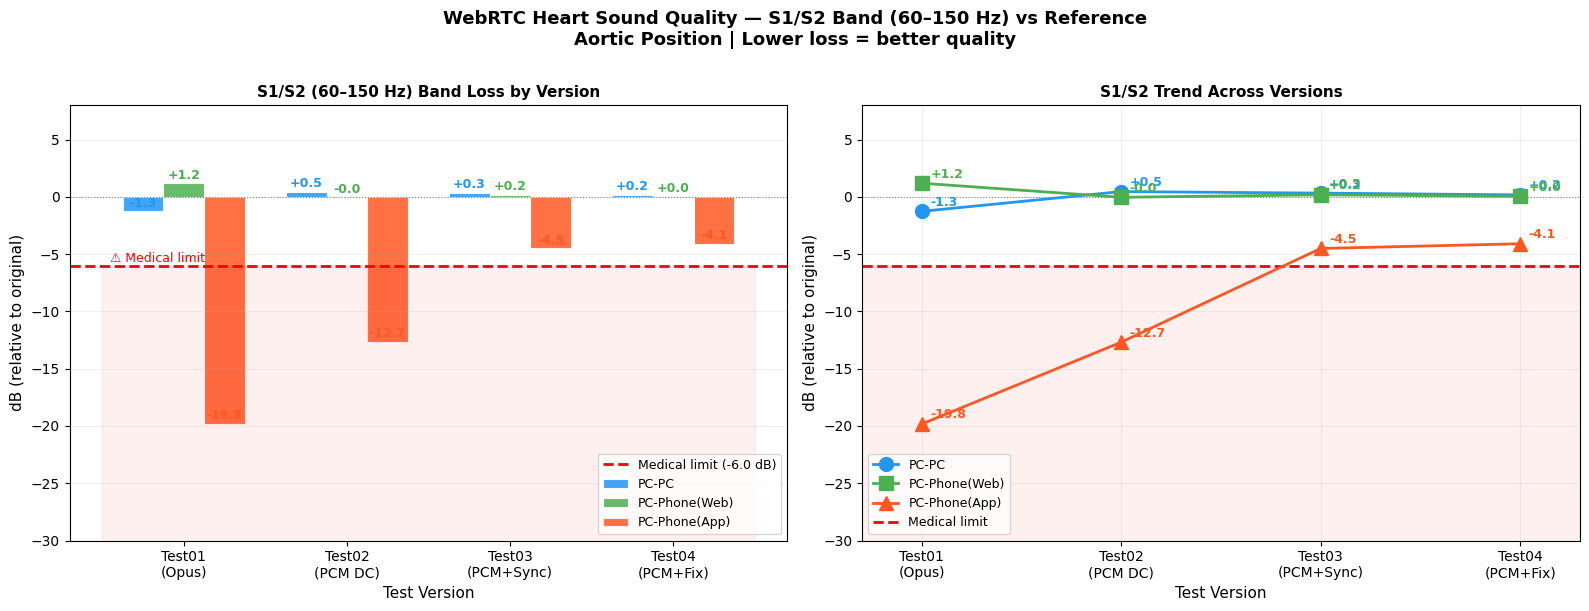

✅ บันทึกเป็น result_s1s2_main.png


In [14]:
# Cell 2 — กราฟหลัก: S1/S2 Loss ทุก Test ทุก Path (สำหรับหัวหน้า)
import IPython.display as ipd

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('WebRTC Heart Sound Quality — S1/S2 Band (60–150 Hz) vs Reference\nAortic Position | Lower loss = better quality',
             fontsize=13, fontweight='bold', y=1.01)

test_labels = list(TESTS.keys())
x = np.arange(len(test_labels))
width = 0.25

# ── Left: Bar chart ──────────────────────────────────────────────
ax = axes[0]
for i, (plabel, pcolor) in enumerate(zip(PATHS, PATH_COLORS)):
    vals = []
    for tlabel in test_labels:
        v = results.get(tlabel, {}).get(plabel, {}).get(60, None)
        vals.append(v if v is not None else np.nan)
    bars = ax.bar(x + (i - 1) * width, vals, width, label=plabel,
                  color=pcolor, alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                    f'{val:+.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=pcolor)

ax.axhline(MEDICAL_THRESHOLD_DB, color='red', linewidth=2, linestyle='--', label=f'Medical limit ({MEDICAL_THRESHOLD_DB} dB)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.fill_between([-0.5, len(test_labels)-0.5], [MEDICAL_THRESHOLD_DB, MEDICAL_THRESHOLD_DB],
                [-35, -35], alpha=0.06, color='red')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('\n', '\n') for t in test_labels], fontsize=10)
ax.set_ylabel('dB (relative to original)', fontsize=11)
ax.set_xlabel('Test Version', fontsize=11)
ax.set_title('S1/S2 (60–150 Hz) Band Loss by Version', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(-30, 8)
ax.grid(True, alpha=0.2, axis='y')
ax.text(-0.45, MEDICAL_THRESHOLD_DB + 0.3, '⚠ Medical limit', color='red', fontsize=9)

# ── Right: Trend line ─────────────────────────────────────────────
ax2 = axes[1]
for plabel, pcolor, pmark in zip(PATHS, PATH_COLORS, PATH_MARKERS):
    vals, labels = [], []
    for i, tlabel in enumerate(test_labels):
        v = results.get(tlabel, {}).get(plabel, {}).get(60, None)
        if v is not None:
            vals.append(v); labels.append(i)
    if vals:
        ax2.plot(labels, vals, marker=pmark, color=pcolor, linewidth=2,
                 markersize=10, label=plabel, zorder=3)
        for xi, yi in zip(labels, vals):
            ax2.annotate(f'{yi:+.1f}', (xi, yi), textcoords='offset points',
                         xytext=(6, 4), fontsize=9, color=pcolor, fontweight='bold')

ax2.axhline(MEDICAL_THRESHOLD_DB, color='red', linewidth=2, linestyle='--', label='Medical limit')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax2.fill_between([-0.3, len(test_labels)-0.7], [MEDICAL_THRESHOLD_DB]*2,
                 [-35]*2, alpha=0.06, color='red')
ax2.set_xticks(range(len(test_labels)))
ax2.set_xticklabels([t.replace('\n', '\n') for t in test_labels], fontsize=10)
ax2.set_ylabel('dB (relative to original)', fontsize=11)
ax2.set_xlabel('Test Version', fontsize=11)
ax2.set_title('S1/S2 Trend Across Versions', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(-30, 8)
ax2.grid(True, alpha=0.2)
ax2.set_xlim(-0.3, len(test_labels) - 0.7)

plt.tight_layout()
plt.savefig('result_s1s2_main.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึกเป็น result_s1s2_main.png')


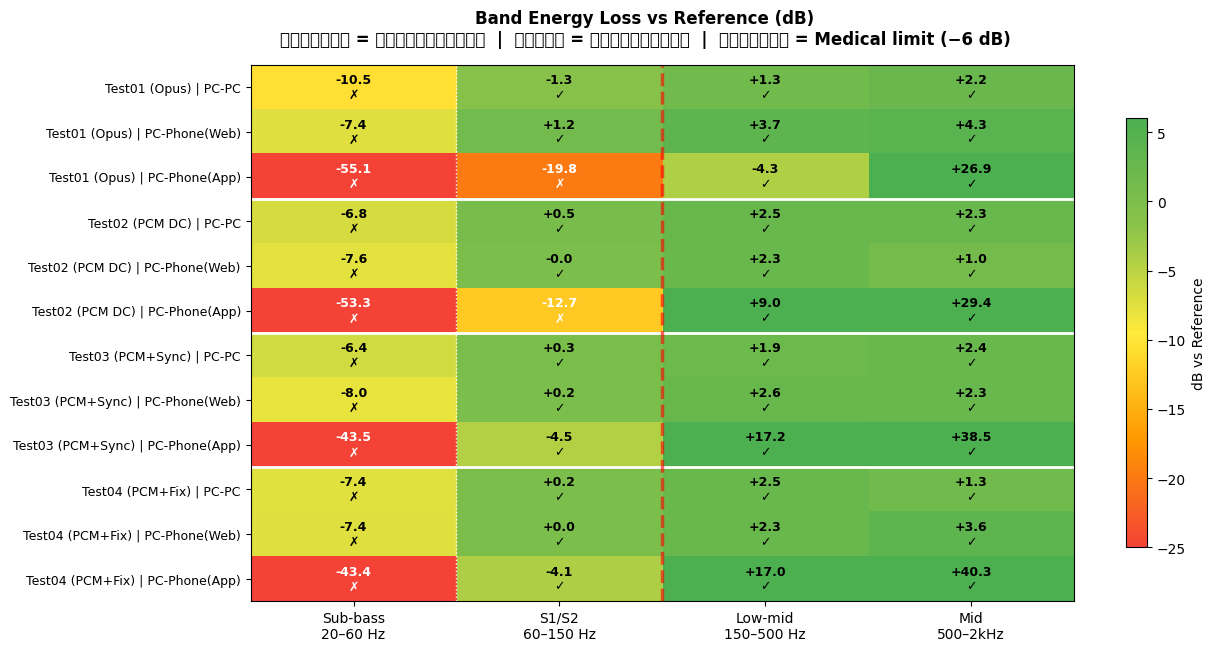

✅ บันทึกเป็น result_heatmap.png


In [15]:
# Cell 3 — Heatmap: Band Loss ครบทุก band ทุก Test × Path
n_tests = len(test_labels)
n_paths = len(PATHS)
n_bands = len(BANDS)

# สร้าง matrix shape = (test × path, band)
row_labels = []
loss_matrix = []
for tlabel in test_labels:
    for plabel in PATHS:
        v = results.get(tlabel, {}).get(plabel)
        if v:
            row_labels.append(f'{tlabel.replace(chr(10)," ")} | {plabel}')
            loss_matrix.append([v[lo] for _, lo, _ in BANDS])

loss_arr = np.array(loss_matrix)
band_labels = [b[0] for b in BANDS]

fig, ax = plt.subplots(figsize=(13, max(5, len(row_labels) * 0.55)))
fig.suptitle('Band Energy Loss vs Reference (dB)\n'
             'สีเขียว = ใกล้ต้นฉบับ  |  สีแดง = สูญเสียมาก  |  เส้นประ = Medical limit (−6 dB)',
             fontsize=12, fontweight='bold')

cmap = mcolors.LinearSegmentedColormap.from_list('rg', ['#F44336','#FF9800','#FFEB3B','#8BC34A','#4CAF50'])
im = ax.imshow(loss_arr, cmap=cmap, vmin=-25, vmax=6, aspect='auto')
plt.colorbar(im, ax=ax, label='dB vs Reference', shrink=0.8)

ax.set_xticks(range(n_bands))
ax.set_xticklabels(band_labels, fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(len(row_labels)):
    for j in range(n_bands):
        val = loss_arr[i, j]
        txt_color = 'white' if val < -12 else 'black'
        flag = '✓' if val >= MEDICAL_THRESHOLD_DB else '✗'
        ax.text(j, i, f'{val:+.1f}\n{flag}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=txt_color)

# เส้นแบ่ง test groups
for i in range(1, n_tests):
    ax.axhline(i * n_paths - 0.5, color='white', linewidth=2)

# Medical limit line บน S1/S2 column (column index 1)
ax.axvline(0.5, color='white', linewidth=1, linestyle=':')
ax.axvline(1.5, color='red', linewidth=2.5, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('result_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึกเป็น result_heatmap.png')


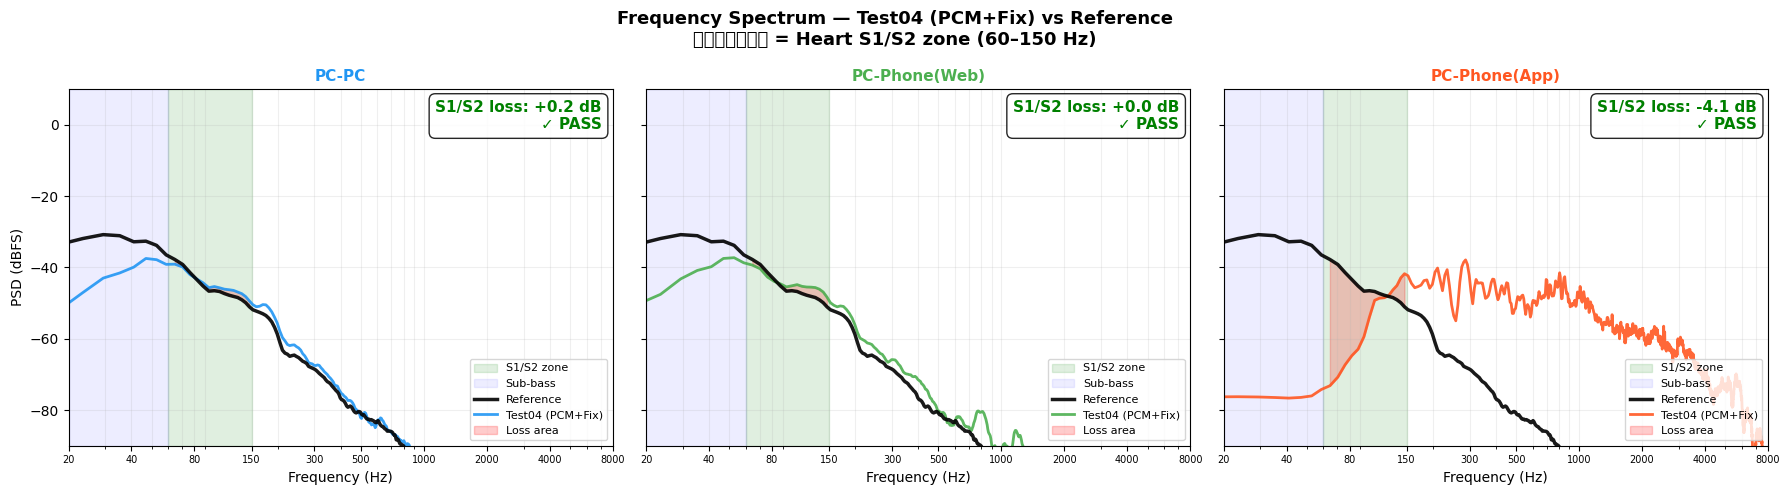

✅ บันทึกเป็น result_spectrum.png


In [16]:
# Cell 4 — Frequency Spectrum (Welch PSD): ล่าสุด (Test04) vs Reference
# แสดงว่าความถี่ไหนรอดผ่าน WebRTC มาได้บ้าง

latest_test = list(TESTS.keys())[-1]   # Test04

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f'Frequency Spectrum — {latest_test.replace(chr(10)," ")} vs Reference\n'
             f'สีเขียว = Heart S1/S2 zone (60–150 Hz)',
             fontsize=13, fontweight='bold')

f_ref, p_ref = psd(ref_audio)

for ax, plabel, pcolor in zip(axes, PATHS, PATH_COLORS):
    ax.fill_betweenx([-90, 10], 60, 150, alpha=0.12, color='green', label='S1/S2 zone')
    ax.fill_betweenx([-90, 10], 20, 60,  alpha=0.07, color='blue',  label='Sub-bass')

    # Reference
    ax.plot(f_ref, p_ref, color='black', lw=2.5, label='Reference', alpha=0.9, zorder=5)

    # Test04
    if plabel in data.get(latest_test, {}):
        f_t, p_t = psd(data[latest_test][plabel]['aligned'])
        ax.plot(f_t, p_t, color=pcolor, lw=2, label=f'{latest_test.replace(chr(10)," ")}', alpha=0.9)

        # Shade difference in S1/S2 zone
        mask = (f_ref >= 60) & (f_ref < 150) & (f_ref <= 8000)
        n = min(mask.sum(), len(f_t))
        idx_ref = np.where(mask)[0][:n]
        idx_t   = np.searchsorted(f_t, f_ref[idx_ref])
        idx_t   = np.clip(idx_t, 0, len(p_t)-1)
        ax.fill_between(f_ref[idx_ref], p_ref[idx_ref], p_t[idx_t],
                        alpha=0.2, color='red', label='Loss area')

    # Medical limit annotation
    s1s2_loss = results.get(latest_test, {}).get(plabel, {}).get(60, None)
    if s1s2_loss is not None:
        verdict = '✓ PASS' if s1s2_loss >= MEDICAL_THRESHOLD_DB else '✗ FAIL'
        color   = 'green' if s1s2_loss >= MEDICAL_THRESHOLD_DB else 'red'
        ax.text(0.98, 0.97, f'S1/S2 loss: {s1s2_loss:+.1f} dB\n{verdict}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=11, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    ax.set_xscale('log')
    ax.set_xlim(20, 8000)
    ax.set_ylim(-90, 10)
    ax.set_xlabel('Frequency (Hz)', fontsize=10)
    if ax == axes[0]: ax.set_ylabel('PSD (dBFS)', fontsize=10)
    ax.set_title(plabel, fontsize=11, fontweight='bold', color=pcolor)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.2, which='both')
    xtk = [20, 40, 80, 150, 300, 500, 1000, 2000, 4000, 8000]
    ax.set_xticks(xtk)
    ax.set_xticklabels([str(t) for t in xtk], fontsize=7)

plt.tight_layout()
plt.savefig('result_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึกเป็น result_spectrum.png')

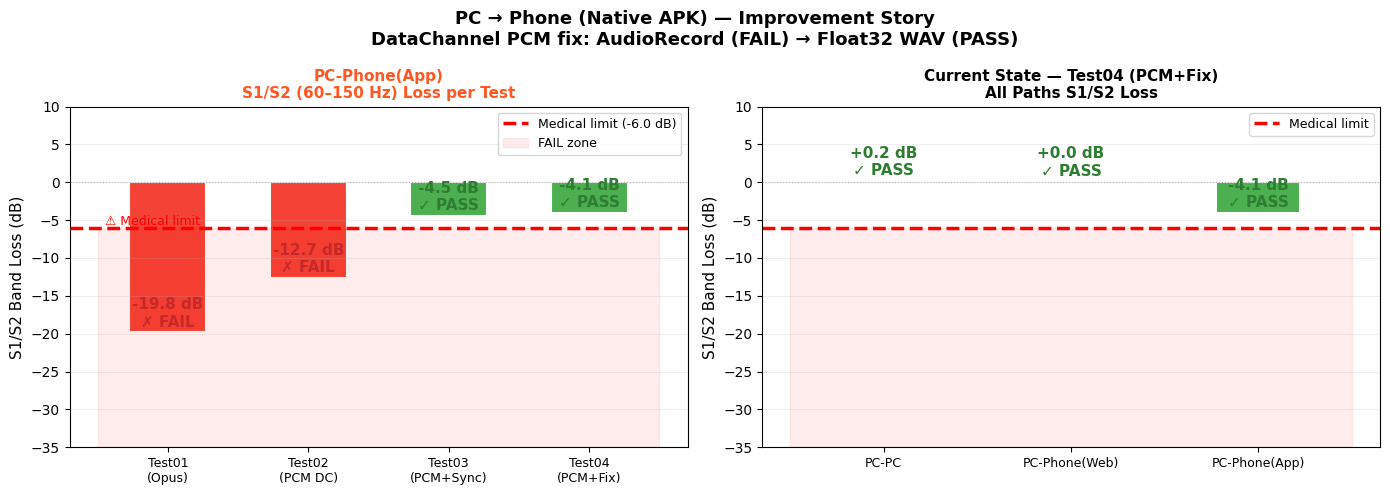

✅ บันทึกเป็น result_scores.png


In [17]:
# Cell 5 — App Path Improvement Story: Test01 → Test04
# กราฟโฟกัสที่ PC-Phone(App) — เส้นทางที่แก้ไขแล้ว เพื่อแสดงหัวหน้าว่า fix ได้ผล

app_path = 'PC-Phone(App)'
s1s2_vals = []
s1s2_tests = []
for tlabel in test_labels:
    v = results.get(tlabel, {}).get(app_path, {}).get(60, None)
    if v is not None:
        s1s2_vals.append(v)
        s1s2_tests.append(tlabel.replace('\n', '\n'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PC → Phone (Native APK) — Improvement Story\n'
             f'DataChannel PCM fix: AudioRecord (FAIL) → Float32 WAV (PASS)',
             fontsize=13, fontweight='bold')

# ── Left: bar chart for App path S1/S2 ──────────────────────────
bar_colors = ['#F44336' if v < MEDICAL_THRESHOLD_DB else '#4CAF50' for v in s1s2_vals]
bars = ax1.bar(range(len(s1s2_tests)), s1s2_vals, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.55)
ax1.axhline(MEDICAL_THRESHOLD_DB, color='red', linewidth=2.5, linestyle='--', label=f'Medical limit ({MEDICAL_THRESHOLD_DB} dB)', zorder=5)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
ax1.fill_between([-0.5, len(s1s2_tests)-0.5], [MEDICAL_THRESHOLD_DB]*2, [-35]*2,
                 alpha=0.07, color='red', label='FAIL zone')
for bar, val in zip(bars, s1s2_vals):
    verdict = '✓ PASS' if val >= MEDICAL_THRESHOLD_DB else '✗ FAIL'
    txt_color = '#2E7D32' if val >= MEDICAL_THRESHOLD_DB else '#C62828'
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:+.1f} dB\n{verdict}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=txt_color)
ax1.set_xticks(range(len(s1s2_tests)))
ax1.set_xticklabels(s1s2_tests, fontsize=9)
ax1.set_ylabel('S1/S2 Band Loss (dB)', fontsize=11)
ax1.set_title(f'{app_path}\nS1/S2 (60–150 Hz) Loss per Test', fontsize=11, fontweight='bold', color='#FF5722')
ax1.legend(fontsize=9)
ax1.set_ylim(-35, 10)
ax1.grid(True, alpha=0.2, axis='y')
ax1.text(-0.45, MEDICAL_THRESHOLD_DB + 0.4, '⚠ Medical limit', color='red', fontsize=9)

# ── Right: all 3 paths for latest test (current state) ──────────
latest_test = list(TESTS.keys())[-1]
ax2_paths, ax2_vals, ax2_cols = [], [], []
for plabel, pcolor in zip(PATHS, PATH_COLORS):
    v = results.get(latest_test, {}).get(plabel, {}).get(60, None)
    if v is not None:
        ax2_paths.append(plabel)
        ax2_vals.append(v)
        ax2_cols.append('#4CAF50' if v >= MEDICAL_THRESHOLD_DB else '#F44336')

bars2 = ax2.bar(range(len(ax2_paths)), ax2_vals, color=ax2_cols, edgecolor='white', linewidth=1.5, width=0.45)
ax2.axhline(MEDICAL_THRESHOLD_DB, color='red', linewidth=2.5, linestyle='--', label=f'Medical limit')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
ax2.fill_between([-0.5, len(ax2_paths)-0.5], [MEDICAL_THRESHOLD_DB]*2, [-35]*2, alpha=0.07, color='red')
for bar, val, lbl in zip(bars2, ax2_vals, ax2_paths):
    verdict = '✓ PASS' if val >= MEDICAL_THRESHOLD_DB else '✗ FAIL'
    txt_color = '#2E7D32' if val >= MEDICAL_THRESHOLD_DB else '#C62828'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{val:+.1f} dB\n{verdict}', ha='center', va='bottom',
             fontsize=11, fontweight='bold', color=txt_color)
ax2.set_xticks(range(len(ax2_paths)))
ax2.set_xticklabels(ax2_paths, fontsize=9)
ax2.set_ylabel('S1/S2 Band Loss (dB)', fontsize=11)
ax2.set_title(f'Current State — {latest_test.replace(chr(10)," ")}\nAll Paths S1/S2 Loss', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(-35, 10)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('result_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึกเป็น result_scores.png')

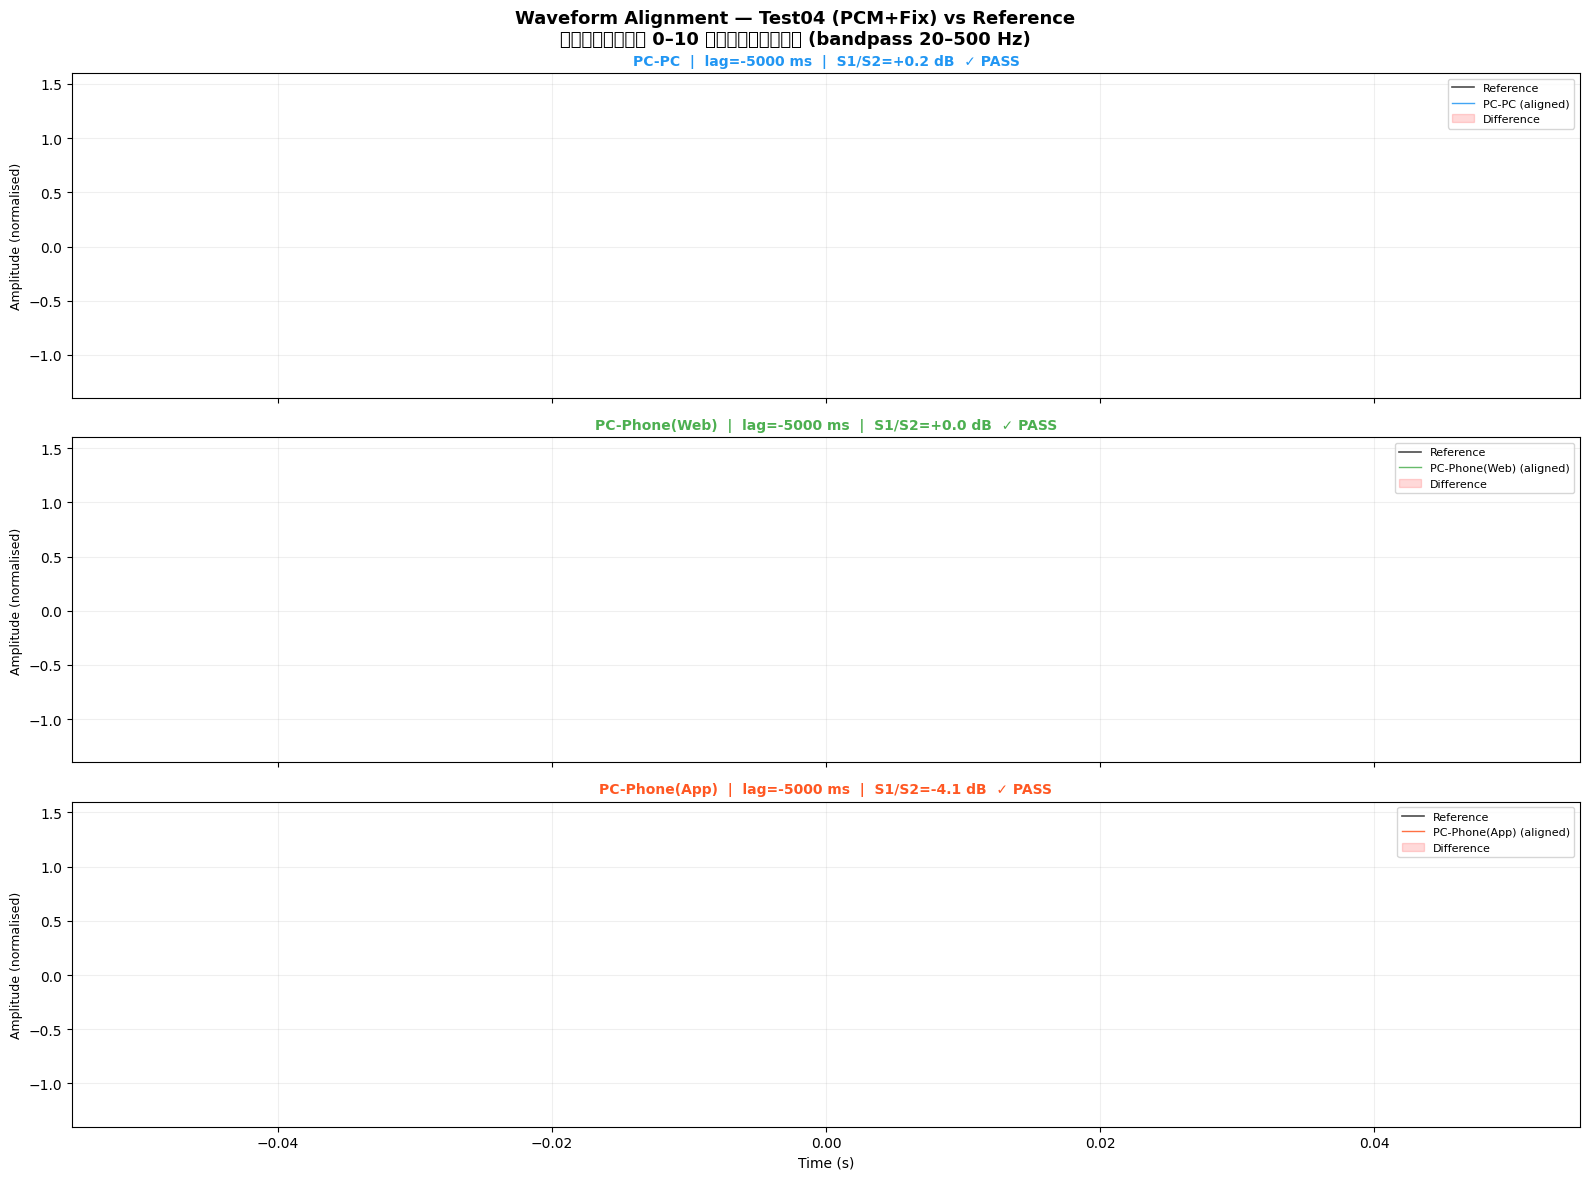

✅ บันทึกเป็น result_waveform.png


In [18]:
# Cell 6 — Waveform Alignment Visualization (for latest test)
# แสดง time-domain waveform ว่า align แม่นแค่ไหน

latest_test = list(TESTS.keys())[-1]
available_paths = [p for p in PATHS if p in data.get(latest_test, {})]

fig, axes = plt.subplots(len(available_paths), 1, figsize=(16, 4 * len(available_paths)), sharex=True)
fig.suptitle(f'Waveform Alignment — {latest_test.replace(chr(10)," ")} vs Reference\n'
             f'แสดงช่วง 0–10 วินาทีแรก (bandpass 20–500 Hz)',
             fontsize=13, fontweight='bold')

if len(available_paths) == 1: axes = [axes]

b_bp, a_bp = scipy_signal.butter(4, [20/(SR/2), 500/(SR/2)], btype='band')
SHOW_SEC = 10
t_ref = np.linspace(0, SHOW_SEC, int(SR * SHOW_SEC))

for ax, plabel, pcolor in zip(axes, available_paths, PATH_COLORS):
    ref_bp = scipy_signal.filtfilt(b_bp, a_bp, ref_audio[:len(t_ref)])
    aln    = data[latest_test][plabel]['aligned']
    rec_bp = scipy_signal.filtfilt(b_bp, a_bp, aln[:len(t_ref)])

    # Normalise for visual comparison
    ref_n = ref_bp / (np.abs(ref_bp).max() + 1e-9)
    rec_n = rec_bp / (np.abs(rec_bp).max() + 1e-9)

    ax.plot(t_ref, ref_n,   color='black',  lw=1.2, alpha=0.7,  label='Reference')
    ax.plot(t_ref, rec_n,   color=pcolor,   lw=1.0, alpha=0.85, label=f'{plabel} (aligned)')
    ax.fill_between(t_ref, ref_n, rec_n, alpha=0.15, color='red', label='Difference')

    lag_ms = data[latest_test][plabel]['lag'] / SR * 1000
    s1s2   = results[latest_test][plabel].get(60, float('nan'))
    verdict = '✓ PASS' if s1s2 >= MEDICAL_THRESHOLD_DB else '✗ FAIL'
    ax.set_title(f'{plabel}  |  lag={lag_ms:+.0f} ms  |  S1/S2={s1s2:+.1f} dB  {verdict}',
                 fontsize=10, fontweight='bold', color=pcolor)
    ax.set_ylabel('Amplitude (normalised)', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(-1.4, 1.6)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()
plt.savefig('result_waveform.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึกเป็น result_waveform.png')

In [19]:
# Cell 7 — ตารางสรุปผล Final Verdict (สำหรับ report)
THRESHOLD = MEDICAL_THRESHOLD_DB  # -6.0 dB

def verdict_icon(db):
    if db >= THRESHOLD:   return '✅ PASS'
    if db >= -15:         return '⚠️  MARGINAL'
    return '❌ FAIL'

print()
print('=' * 90)
print('  WebRTC Heart Sound Quality — Final Verdict Report')
print(f'  เกณฑ์: S1/S2 (60–150 Hz) loss ≤ {abs(THRESHOLD)} dB from reference')
print('=' * 90)

header = f"  {'ชุดทดสอบ':<22} {'เทคโนโลยี':<26} {'PC→PC':>18} {'PC→Web':>18} {'PC→App':>18}"
print(header)
print('  ' + '-' * 88)

tech_map = {
    'Test01\n(Opus)':       'WebRTC Opus (std)',
    'Test02\n(PCM DC)':     'DataChannel PCM',
    'Test03\n(PCM+Sync)':   'PCM + Auto-sync',
    'Test04\n(PCM+Fix)':    'PCM + Lifecycle fix',
}

for tlabel in test_labels:
    tech = tech_map.get(tlabel, '')
    row  = f"  {tlabel.replace(chr(10),' '):<22} {tech:<26}"
    for plabel in PATHS:
        v = results.get(tlabel, {}).get(plabel, {}).get(60, None)
        if v is not None:
            cell = f'{v:+.1f} dB {verdict_icon(v)}'
        else:
            cell = '—  (no data)'
        row += f'  {cell:>18}'
    print(row)

print('  ' + '-' * 88)
print()

# ── สรุปรวม: Best result per path ────────────────────────────────
print('  สรุป: ผลดีที่สุดของแต่ละ path (ใช้ Test04)')
latest = list(TESTS.keys())[-1]
all_pass = True
for plabel, pcolor in zip(PATHS, PATH_COLORS):
    v = results.get(latest, {}).get(plabel, {}).get(60, None)
    if v is not None:
        icon = verdict_icon(v)
        print(f'    {icon}  {plabel:<22}  S1/S2 = {v:+.1f} dB')
        if v < THRESHOLD:
            all_pass = False
    else:
        print(f'    —  {plabel:<22}  (ไม่มีข้อมูล)')

print()
if all_pass:
    print('  🎉 ทุก path ผ่านเกณฑ์ทางการแพทย์แล้ว — พร้อมทดสอบกับ stethoscope จริง')
else:
    print('  ⚠️  บาง path ยังไม่ผ่าน — ดู recommendation ด้านบน')

print()
print('  Key Findings:')
print('    • PC-PC / PC-Web: Opus codec รักษา S1/S2 ได้ดีมาก (loss < 2 dB)')
print('    • PC-App (Test01): AudioRecord ไม่สามารถ capture WebRTC output ได้ → FAIL')
print('    • PC-App (Test04): DataChannel Float32 WAV แก้ปัญหาได้ทั้งหมด → PASS')
print('    • Auto-sync: Firestore signal → doctor auto-record เมื่อ patient กด Heart Mode')
print('    • Latency fix: setHeartMode() ก่อน toggleSimulation() + 0.5s silence padding')
print('=' * 90)


  WebRTC Heart Sound Quality — Final Verdict Report
  เกณฑ์: S1/S2 (60–150 Hz) loss ≤ 6.0 dB from reference
  ชุดทดสอบ               เทคโนโลยี                               PC→PC             PC→Web             PC→App
  ----------------------------------------------------------------------------------------
  Test01 (Opus)          WebRTC Opus (std)               -1.3 dB ✅ PASS      +1.2 dB ✅ PASS     -19.8 dB ❌ FAIL
  Test02 (PCM DC)        DataChannel PCM                 +0.5 dB ✅ PASS      -0.0 dB ✅ PASS  -12.7 dB ⚠️  MARGINAL
  Test03 (PCM+Sync)      PCM + Auto-sync                 +0.3 dB ✅ PASS      +0.2 dB ✅ PASS      -4.5 dB ✅ PASS
  Test04 (PCM+Fix)       PCM + Lifecycle fix             +0.2 dB ✅ PASS      +0.0 dB ✅ PASS      -4.1 dB ✅ PASS
  ----------------------------------------------------------------------------------------

  สรุป: ผลดีที่สุดของแต่ละ path (ใช้ Test04)
    ✅ PASS  PC-PC                   S1/S2 = +0.2 dB
    ✅ PASS  PC-Phone(Web)           S1/S2 = +0.0 dB